# Reconocimiento e Identificación de Placas Vehiculares — v4
### Módulo 3 · Visión por Computadora · Diplomado RNA y Deep Learning
---
## Diagnóstico v3 → Mejoras v4

| Problema (v3) | Causa raíz | Solución (v4) |
|---------------|-----------|---------------|
| placa3 lee EDOMEX | Haar detectó franja logo, no la de números | Expandir ROI 100% hacia abajo |
| placa2 OCR cadena gigante | PSM 7 lee todo el fondo como una línea | Límite 12 chars + validador de formato |
| placa6 sigue detectando árboles | AR filter no distingue árbol de placa | Filtro de brillo: placas claras > 80 |
| placa4 fallback lee TRANSPORTE | Zone crop de imagen completa ≠ zona de placa | Fallback sin zone crop |

## Idea  → Validador de formato  ✨

observamos sobre el '-' es posiblemente **postprocesamiento por formato**

```
MX EdomEx  →  AAA-##-##   (2 guiones, 3L-2N-2N)
MX CDMX    →  AAA-##-##   (mismo formato)
EU España  →  #### AAA    (4 números + 3 letras, sin guión)
CO Colombia→  AAA-###     (1 guión, 3L-3N)
```

Entre las 5 variantes de OCR, el validador elige la que mejor **encaja
con el patrón esperado** para el tipo de placa detectado.


---
## Notas de Instalación — Tesseract OCR

> **Pytesseract** es solo un *wrapper* Python. El motor real es **Tesseract**,
> que debe instalarse por separado en el sistema operativo.

### Windows 11
```
1. Descargar: https://github.com/UB-Mannheim/tesseract/wiki
   Archivo: tesseract-ocr-w64-setup-*.exe  (64-bit)
2. Instalar con opciones por default.
   Ruta: C:\Program Files\Tesseract-OCR\tesseract.exe
3. Reiniciar el sistema o kernel de Jupyter/VSCode.
   La línea tesseract_cmd en Celda 1 lo configura automáticamente.
```

### Ubuntu (máquina de la escuela)
```bash
sudo apt update && sudo apt install tesseract-ocr libtesseract-dev
tesseract --version   # NO se necesita setear tesseract_cmd
```

### Google Colab
```python
!sudo apt install tesseract-ocr -q
!pip install pytesseract -q
from google.colab import drive
drive.mount('/content/drive')
# NO se necesita setear tesseract_cmd
```


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import platform
import re
import pytesseract

if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

RUTA_PLACAS     = os.path.join('..', 'Material', 'Plates')
EXTENSIONES_IMG = ('.jpg', '.jpeg', '.png', '.bmp')
KERNEL_MORPH    = np.ones((2, 2), np.uint8)

OCR_CFG = {
    'MX' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'EU' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789',
    'CO' : '--psm 7 --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'GEN': '--psm 6 --oem 3',
}

# ── Patrones de formato por tipo ─────────────────────────────────────────
# El validador usa estos regex para encontrar qué variante OCR es la correcta
# re.search busca el patrón EN CUALQUIER PARTE del string
# → tolerante a caracteres extra que Tesseract haya leído alrededor
PATRON = {
    'MX' : re.compile(r'[A-Z]{2,3}[-]?[0-9]{2}[-]?[0-9]{2}'),  # AAA-##-##
    'EU' : re.compile(r'[0-9]{3,4}[A-Z]{2,3}'),                 # ####AAA
    'CO' : re.compile(r'[A-Z]{3}[-]?[0-9]{3}'),                 # AAA-###
    'GEN': re.compile(r'[A-Z0-9]{4,8}'),                        # genérico
}

GROUND_TRUTH = {
    'placa1.jpg': ('LRV5977', 'MX'),
    'placa2.jpg': ('5649JSN', 'EU'),
    'placa3.jpg': ('NLU9603', 'MX'),
    'placa4.jpg': ('NAA7741', 'MX'),
    'placa5.jpg': ('BNR249',  'CO'),
    'placa6.jpg': ('NNR7087', 'MX'),
    'placa7.jpg': ('470MJV',  'MX'),
}

print(f'Sistema   : {platform.system()}')
print(f'Tesseract : {pytesseract.get_tesseract_version()}')
print('Imports y patrones de formato listos ✅')


Sistema   : Windows
Tesseract : 5.5.0.20241111
Imports y patrones de formato listos ✅


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Haar Cascade + cargar_imagenes()
# ═══════════════════════════════════════════════════════════════

plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)

def cargar_imagenes(ruta_carpeta, prefijos=None, ordenar=True):
    if not os.path.isdir(ruta_carpeta):
        print(f'Carpeta no encontrada: {os.path.abspath(ruta_carpeta)}')
        return []
    archivos = []
    for nombre in os.listdir(ruta_carpeta):
        if not nombre.lower().endswith(EXTENSIONES_IMG):
            continue
        if prefijos and not nombre.lower().startswith(prefijos):
            continue
        archivos.append(os.path.join(ruta_carpeta, nombre))
    return sorted(archivos) if ordenar else archivos

imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
print(f'Haar cargado ✅  |  {len(imagenes)} imágenes encontradas')


Haar cargado ✅  |  7 imágenes encontradas


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3a — Filtros de detección
# ═══════════════════════════════════════════════════════════════
#
# Dos filtros aplicados en cascada sobre cada ROI detectado por Haar:
#
# FILTRO 1 — Aspect Ratio
#   Las placas vehiculares son horizontales: ancho/alto entre 1.5 y 7.0
#   Descarta cuadrados, rectángulos verticales, ventanas, etc.
#
# FILTRO 2 — Brillo promedio  ← NUEVO en v4
#   Las placas tienen fondo blanco/claro → brillo alto
#   Los árboles, asfalto, carrocería oscura → brillo bajo
#   Medimos el brillo del 60% CENTRAL del ROI (evitamos los bordes)
#   Si el brillo medio < BRILLO_MIN → probablemente no es una placa
#
#   Calibración con el dataset:
#     Placa blanca (placa1): brillo ~200
#     Árboles/pasto (placa6): brillo ~70-90
#     Anuncio Coppel (placa7): brillo ~140 (color azul/amarillo)
#     BRILLO_MIN = 100 → discrimina árboles, deja pasar placas y algunos letreros

AR_MIN     = 1.5
AR_MAX     = 7.0
BRILLO_MIN = 100    # 0-255; placas claras superan este umbral

def filtrar_rois(detecciones, img_gris):
    """
    Aplica filtros AR y brillo sobre una lista de detecciones Haar.

    Args:
        detecciones : lista/array de (x, y, w, h)
        img_gris    : imagen original en escala de grises

    Returns:
        validas    : lista de (x, y, w, h) que pasaron ambos filtros
        rechazadas : lista de strings describiendo qué se descartó y por qué
    """
    validas    = []
    rechazadas = []

    for det in detecciones:
        x, y, w, h = det

        # Filtro 1: Aspect Ratio
        ar = w / h if h > 0 else 0
        if not (AR_MIN <= ar <= AR_MAX):
            rechazadas.append(f'AR={ar:.1f} fuera de [{AR_MIN}-{AR_MAX}]')
            continue

        # Filtro 2: Brillo — zona central del ROI
        # Recortamos el 20%-80% horizontal y 10%-90% vertical
        # para evitar que los bordes oscuros del marco contaminen la medición
        roi = img_gris[y:y+h, x:x+w]
        if roi.size == 0:
            rechazadas.append('ROI vacío')
            continue

        cy1 = int(roi.shape[0] * 0.10)
        cy2 = int(roi.shape[0] * 0.90)
        cx1 = int(roi.shape[1] * 0.20)
        cx2 = int(roi.shape[1] * 0.80)
        zona_central = roi[cy1:cy2, cx1:cx2]

        brillo = np.mean(zona_central) if zona_central.size > 0 else 0

        if brillo < BRILLO_MIN:
            rechazadas.append(f'brillo={brillo:.0f} < {BRILLO_MIN} (árbol/oscuro)')
            continue

        validas.append(det)

    return validas, rechazadas

print('Función filtrar_rois() lista ✅')
print(f'  Filtro AR     : {AR_MIN} – {AR_MAX}')
print(f'  Filtro brillo : mínimo {BRILLO_MIN}/255 en zona central')


Función filtrar_rois() lista ✅
  Filtro AR     : 1.5 – 7.0
  Filtro brillo : mínimo 100/255 en zona central


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3b — Función: identificar_tipo_placa()
# ═══════════════════════════════════════════════════════════════

def identificar_tipo_placa(img_placa_rgb):
    """
    Identifica tipo: 'EU', 'CO' o 'MX' por análisis de color.
    EU → franja azul izquierda | CO → fondo amarillo | MX → default
    """
    h, w = img_placa_rgb.shape[:2]
    img_hsv = cv2.cvtColor(img_placa_rgb, cv2.COLOR_RGB2HSV)

    franja_izq   = img_hsv[:, :int(w * 0.15)]
    m_azul       = cv2.inRange(franja_izq, np.array([100,100,80]), np.array([135,255,255]))
    total_izq    = franja_izq.shape[0] * franja_izq.shape[1]
    score_eu     = cv2.countNonZero(m_azul) / total_izq * 100 if total_izq > 0 else 0

    m_am         = cv2.inRange(img_hsv, np.array([20,150,150]), np.array([35,255,255]))
    score_co     = cv2.countNonZero(m_am) / (h * w) * 100 if h * w > 0 else 0

    info = {'score_eu': round(score_eu,1), 'score_co': round(score_co,1)}

    if score_eu > 20:  return 'EU', info
    if score_co > 12:  return 'CO', info
    return 'MX', info

print('Función identificar_tipo_placa() lista ✅')


Función identificar_tipo_placa() lista ✅


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3c — Función: detectar_placas() con expansión de ROI
# ═══════════════════════════════════════════════════════════════
#
# PROBLEMA v3 (placa3): Haar detectó la franja del LOGO de la placa
# (la tira de arriba con 'EDOMEX'), no la franja de los números.
# Cuando aplicábamos zone crop 45-90%, seguíamos dentro del logo.
#
# SOLUCIÓN — Expansión de ROI ← NUEVA en v4
#
# Si Haar detecta una región MUY DELGADA (h < 60px o AR > 5.0)
# es probable que haya capturado solo la franja superior.
# Expandimos el bounding box HACIA ABAJO por ROI_EXPAND_FACTOR × h.
#
# Ejemplo:
#   Haar detecta: x=100, y=50, w=300, h=40  (franja logo, AR=7.5 → pasa por ser < AR_MAX)
#   Expandido:    y=50,  h=40+40×1.5 = 100  (ahora incluye la zona de números)
#
# ROI_EXPAND_FACTOR = 1.5 → agrega 150% del alto hacia abajo

ROI_EXPAND_FACTOR = 1.5

def expandir_roi(x, y, w, h, img_shape):
    """
    Expande un ROI hacia abajo si parece una franja delgada.
    Recorta al tamaño de la imagen para no salir de los bordes.
    """
    img_h, img_w = img_shape[:2]
    ar = w / h if h > 0 else 0

    # Expandir si es delgado (AR > 5) o muy bajo en píxeles absolutos
    if ar > 5.0 or h < 50:
        extra = int(h * ROI_EXPAND_FACTOR)
        h_new = min(h + extra, img_h - y)  # no salir de la imagen
        return x, y, w, h_new, True

    return x, y, w, h, False


def detectar_placas(ruta_imagen):
    """
    Detecta placas con 4 intentos + filtros AR/brillo + expansión de ROI.

    Returns:
        img_rgb     : imagen original en RGB
        recortes    : lista de ROIs expandidos y recortados
        coords      : lista de (x, y, w, h) finales
        intento     : número de intento exitoso (0 = fallback)
        es_fallback : bool — True si se usó la imagen completa
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}')
        return None, [], [], -1, False

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    intentos = [
        (1.10, 5, (60, 20), 'estandar'),
        (1.05, 3, (40, 15), 'permisivo'),
        (1.03, 1, (30, 10), 'ultra-permisivo'),
        (1.03, 1, (20,  8), 'escena-calle'),
    ]

    for num, (scale, vecinos, minsize, desc) in enumerate(intentos, 1):
        dets_raw = plate_cascade.detectMultiScale(
            img_gris, scaleFactor=scale, minNeighbors=vecinos, minSize=minsize
        )
        if len(dets_raw) == 0:
            continue

        dets_validas, rechazadas = filtrar_rois(dets_raw, img_gris)

        if rechazadas:
            print(f'  Intento {num}: {len(rechazadas)} rechazada(s): {rechazadas[:3]}')

        if not dets_validas:
            continue

        # Expandir cada ROI válido
        coords_finales = []
        for det in dets_validas:
            xn, yn, wn, hn, expandido = expandir_roi(*det, img_gris.shape)
            coords_finales.append((xn, yn, wn, hn))
            if expandido:
                print(f'    ROI expandido: {det[2]}x{det[3]} → {wn}x{hn}')

        # Ordenar por área descendente
        coords_finales = sorted(coords_finales, key=lambda r: r[2]*r[3], reverse=True)
        recortes = [img_rgb[y:y+h, x:x+w] for (x, y, w, h) in coords_finales]

        print(f'  Intento {num} ({desc}): {len(coords_finales)} válida(s)')
        return img_rgb, recortes, coords_finales, num, False

    # Fallback
    print('  Haar: sin detecciones → fallback imagen completa')
    hf, wf = img_rgb.shape[:2]
    return img_rgb, [img_rgb], [(0, 0, wf, hf)], 0, True

print('Función detectar_placas() lista ✅')


Función detectar_placas() lista ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3d — Función: validar_formato()  ← NUEVA en v4
# ═══════════════════════════════════════════════════════════════
#
# La idea sobre detectar '-' para saber si el OCR encontró los números:
# Dado un dict de variantes OCR, elegimos la que
# mejor encaja con el patrón esperado para ese tipo de placa.
#
# ESTRATEGIA de selección (en orden de prioridad):
#   1. Si alguna variante HACE MATCH con el regex del tipo → esa gana
#      (la más larga entre las que hacen match)
#   2. Si ninguna hace match → fallback: la más larga de todas
#      (igual que v1-v3, pero ahora es el último recurso)
#
# Ejemplo MX (patrón: [A-Z]{2,3}[-]?[0-9]{2}[-]?[0-9]{2}):
#   otsu=[2BDORSEI]   → match? NO
#   adapt=[EDOALEX]   → match? NO
#   fija=[NLU9603]    → match? SÍ (NLU96 encaja) → GANADORA
#
# Resultado también se limita a 12 caracteres máximo
# (solución al problema de placa2 con cadenas gigantes)

MAX_OCR_LEN = 12   # más de 12 chars es casi seguro ruido en una placa

def validar_formato(variantes_ocr, tipo):
    """
    Elige la mejor variante OCR usando el patrón de formato del tipo de placa.

    Args:
        variantes_ocr : dict {nombre: texto_ocr}
        tipo          : 'MX', 'EU', 'CO' o 'GEN'

    Returns:
        texto_final   : str → mejor texto seleccionado (máx 12 chars)
        metodo        : str → nombre de la variante ganadora
        match_formato : bool → True si hizo match con el regex
    """
    patron = PATRON.get(tipo, PATRON['GEN'])

    # Limpiar y limitar longitud
    candidatos = {}
    for nombre, texto in variantes_ocr.items():
        limpio = texto[:MAX_OCR_LEN]  # cortar si es muy largo
        candidatos[nombre] = limpio

    # Prioridad 1: variantes que hacen match con el patrón del tipo
    con_match = {n: t for n, t in candidatos.items() if patron.search(t)}

    if con_match:
        # De las que hacen match, preferir la más larga
        metodo = max(con_match, key=lambda n: len(con_match[n]))
        return con_match[metodo], metodo, True

    # Prioridad 2: fallback → la más larga de todas
    metodo = max(candidatos, key=lambda n: len(candidatos[n]))
    return candidatos[metodo], metodo, False

print('Función validar_formato() lista ✅')
print(f'  Patrones cargados para: {list(PATRON.keys())}')
print(f'  Longitud máxima OCR: {MAX_OCR_LEN} caracteres')


Función validar_formato() lista ✅
  Patrones cargados para: ['MX', 'EU', 'CO', 'GEN']
  Longitud máxima OCR: 12 caracteres


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3e — Función: extraer_texto()
# ═══════════════════════════════════════════════════════════════
#
# Cambio v4:
#   - Zone crop SOLO si NO es fallback (fix placa4 fallback)
#   - Selección final por validar_formato() en lugar de max(len)
#   - Se guarda el método ganador y si hizo match

def extraer_texto(img_placa_rgb, tipo='MX', es_fallback=False, escala=2.0):
    """
    Extrae texto con pipeline completo y validación de formato.

    Args:
        img_placa_rgb : recorte de la placa en RGB
        tipo          : 'MX', 'EU', 'CO' o 'GEN'
        es_fallback   : si True, no aplica zone crop (imagen ya es full)
        escala        : factor de escalado

    Returns:
        texto_final  : str  → texto reconocido
        detalle      : dict → resultado por variante
        metodo       : str  → variante ganadora
        match        : bool → True si encajó con el patrón de formato
        etapas       : dict → imágenes del pipeline
    """
    config_ocr = OCR_CFG.get(tipo, OCR_CFG['GEN'])

    # ── Zone crop ─────────────────────────────────────────────
    # Solo para placas MX con detección Haar (no fallback).
    # Fallback = imagen completa → crop no tiene sentido.
    if tipo == 'MX' and not es_fallback:
        h_img = img_placa_rgb.shape[0]
        zona  = img_placa_rgb[int(h_img * 0.45): int(h_img * 0.90), :]
        img_base = zona if zona.shape[0] > 10 else img_placa_rgb
    else:
        img_base = img_placa_rgb

    # ── Pipeline ──────────────────────────────────────────────
    h, w   = img_base.shape[:2]
    img_esc = cv2.resize(img_base, (int(w*escala), int(h*escala)),
                         interpolation=cv2.INTER_CUBIC)
    img_gris = cv2.cvtColor(img_esc, cv2.COLOR_RGB2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_cla  = clahe.apply(img_gris)
    img_med  = cv2.medianBlur(img_cla, 3)

    _, bin_otsu  = cv2.threshold(img_med, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bin_adapt    = cv2.adaptiveThreshold(img_med, 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)
    _, bin_fija  = cv2.threshold(img_med, 127, 255, cv2.THRESH_BINARY)

    morph_otsu  = cv2.morphologyEx(bin_otsu,  cv2.MORPH_CLOSE, KERNEL_MORPH)
    morph_adapt = cv2.morphologyEx(bin_adapt, cv2.MORPH_CLOSE, KERNEL_MORPH)

    # ── OCR ───────────────────────────────────────────────────
    variantes = {
        'otsu'        : bin_otsu,
        'otsu_morph'  : morph_otsu,
        'adapt'       : bin_adapt,
        'adapt_morph' : morph_adapt,
        'fija'        : bin_fija,
    }
    detalle = {}
    for nombre, img_bin in variantes.items():
        raw    = pytesseract.image_to_string(img_bin, config=config_ocr)
        limpio = ''.join(c for c in raw.upper() if c.isalnum() or c == '-')
        detalle[nombre] = limpio

    # ── Selección por validador de formato ────────────────────
    texto_final, metodo, match = validar_formato(detalle, tipo)

    etapas = {
        'original'   : img_placa_rgb,
        'zona_numeros': img_base,
        'clahe'      : img_cla,
        'bin_otsu'   : bin_otsu,
        'morph_otsu' : morph_otsu,
        'bin_adapt'  : bin_adapt,
    }
    return texto_final, detalle, metodo, match, etapas

print('Función extraer_texto() lista ✅')


Función extraer_texto() lista ✅


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Procesamiento completo
# ═══════════════════════════════════════════════════════════════

imagenes   = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
resultados = []

for ruta in imagenes:
    nombre = os.path.basename(ruta)
    sep = '=' * 64
    print(f'\n{sep}')
    print(f'  {nombre}')
    print(sep)

    img_rgb, recortes, coords, intento_ok, es_fallback = detectar_placas(ruta)
    if img_rgb is None:
        continue

    recorte     = recortes[0]
    x, y, w, h  = coords[0]
    print(f'  ROI: {w}x{h}px  AR={w/h:.1f}  fallback={es_fallback}')

    tipo, info_tipo = identificar_tipo_placa(recorte)
    print(f'  Tipo: {tipo}  (EU={info_tipo["score_eu"]}%, CO={info_tipo["score_co"]}%)')

    texto, detalle, metodo, match, etapas = extraer_texto(
        recorte, tipo=tipo, es_fallback=es_fallback
    )
    match_str = '✅ match formato' if match else '⚠️  sin match'
    print(f'  OCR: [{texto}]  método={metodo}  {match_str}')
    print(f'  Desglose: ' + '  '.join(f'{k}=[{v}]' for k, v in detalle.items()))

    resultados.append({
        'imagen'     : nombre,
        'tipo'       : tipo,
        'texto'      : texto,
        'detalle'    : detalle,
        'metodo'     : metodo,
        'match'      : match,
        'intento'    : intento_ok,
        'es_fallback': es_fallback,
        'recorte'    : recorte,
        'etapas'     : etapas,
    })

print(f'\n\nProcesamiento completo: {len(resultados)} imagen(es) ✅')



  placa1.jpg
  Haar: sin detecciones → fallback imagen completa
  ROI: 319x158px  AR=2.0  fallback=True
  Tipo: MX  (EU=0.0%, CO=0.0%)
  OCR: [LWW]  método=adapt  ⚠️  sin match
  Desglose: otsu=[]  otsu_morph=[]  adapt=[LWW]  adapt_morph=[]  fija=[]

  placa2.jpg
  Intento 1 (estandar): 2 válida(s)
  ROI: 1066x355px  AR=3.0  fallback=False
  Tipo: EU  (EU=20.7%, CO=0.0%)
  OCR: []  método=otsu  ⚠️  sin match
  Desglose: otsu=[]  otsu_morph=[]  adapt=[]  adapt_morph=[]  fija=[]

  placa3.jpg
  Intento 2 (permisivo): 1 válida(s)
  ROI: 239x79px  AR=3.0  fallback=False
  Tipo: MX  (EU=0.0%, CO=0.0%)
  OCR: [VU0OM-EX]  método=fija  ⚠️  sin match
  Desglose: otsu=[]  otsu_morph=[]  adapt=[]  adapt_morph=[SORE]  fija=[VU0OM-EX]

  placa4.jpg
  Haar: sin detecciones → fallback imagen completa
  ROI: 300x150px  AR=2.0  fallback=True
  Tipo: MX  (EU=1.1%, CO=0.0%)
  OCR: [NAA-77-41]  método=otsu  ✅ match formato
  Desglose: otsu=[NAA-77-41]  otsu_morph=[NAA-77-41]  adapt=[]  adapt_morph=[]  fi

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Tabla de resultados
# ═══════════════════════════════════════════════════════════════

sep = '=' * 82
print('\n' + sep)
print(f'  {"IMAGEN":<12} {"TIPO":<5} {"OCR":<14} {"ESPERADO":<10} '
      f'{"MÉTODO":<14} {"FMT":>4} {"OCR":>4} {"TIPO":>5}')
print(sep)

for r in resultados:
    gt_texto, gt_tipo = GROUND_TRUTH.get(r['imagen'], ('?','?'))
    ocr = r['texto']

    v_ocr  = '✅' if (gt_texto and (gt_texto in ocr or ocr in gt_texto)) else ('—' if not gt_texto else '❌')
    v_tipo = '✅' if r['tipo'] == gt_tipo else '❌'
    v_fmt  = '✅' if r['match'] else '⚠️ '

    print(f'  {r["imagen"]:<12} {r["tipo"]:<5} {ocr:<14} '
          f'{gt_texto:<10} {r["metodo"]:<14} {v_fmt:>4} {v_ocr:>4} {v_tipo:>5}')

print(sep)
print('FMT=match formato  OCR=texto correcto  TIPO=tipo detectado correcto')



  IMAGEN       TIPO  OCR            ESPERADO   MÉTODO          FMT  OCR  TIPO
  placa1.jpg   MX    LWW            LRV5977    adapt           ⚠️     ❌     ✅
  placa2.jpg   EU                   5649JSN    otsu            ⚠️     ✅     ✅
  placa3.jpg   MX    VU0OM-EX       NLU9603    fija            ⚠️     ❌     ✅
  placa4.jpg   MX    NAA-77-41      NAA7741    otsu              ✅    ❌     ✅
  placa5.jpg   MX                   BNR249     otsu            ⚠️     ✅     ❌
  placa6.jpg   MX                   NNR7087    otsu            ⚠️     ✅     ✅
  placa7.jpg   MX    P-             470MJV     otsu_morph      ⚠️     ❌     ✅
FMT=match formato  OCR=texto correcto  TIPO=tipo detectado correcto


C:\Users\Darck\AppData\Local\Temp\ipykernel_14348\958475836.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Darck\AppData\Local\Temp\ipykernel_14348\958475836.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('output_placas_v4.png', dpi=120, bbox_inches='tight')
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


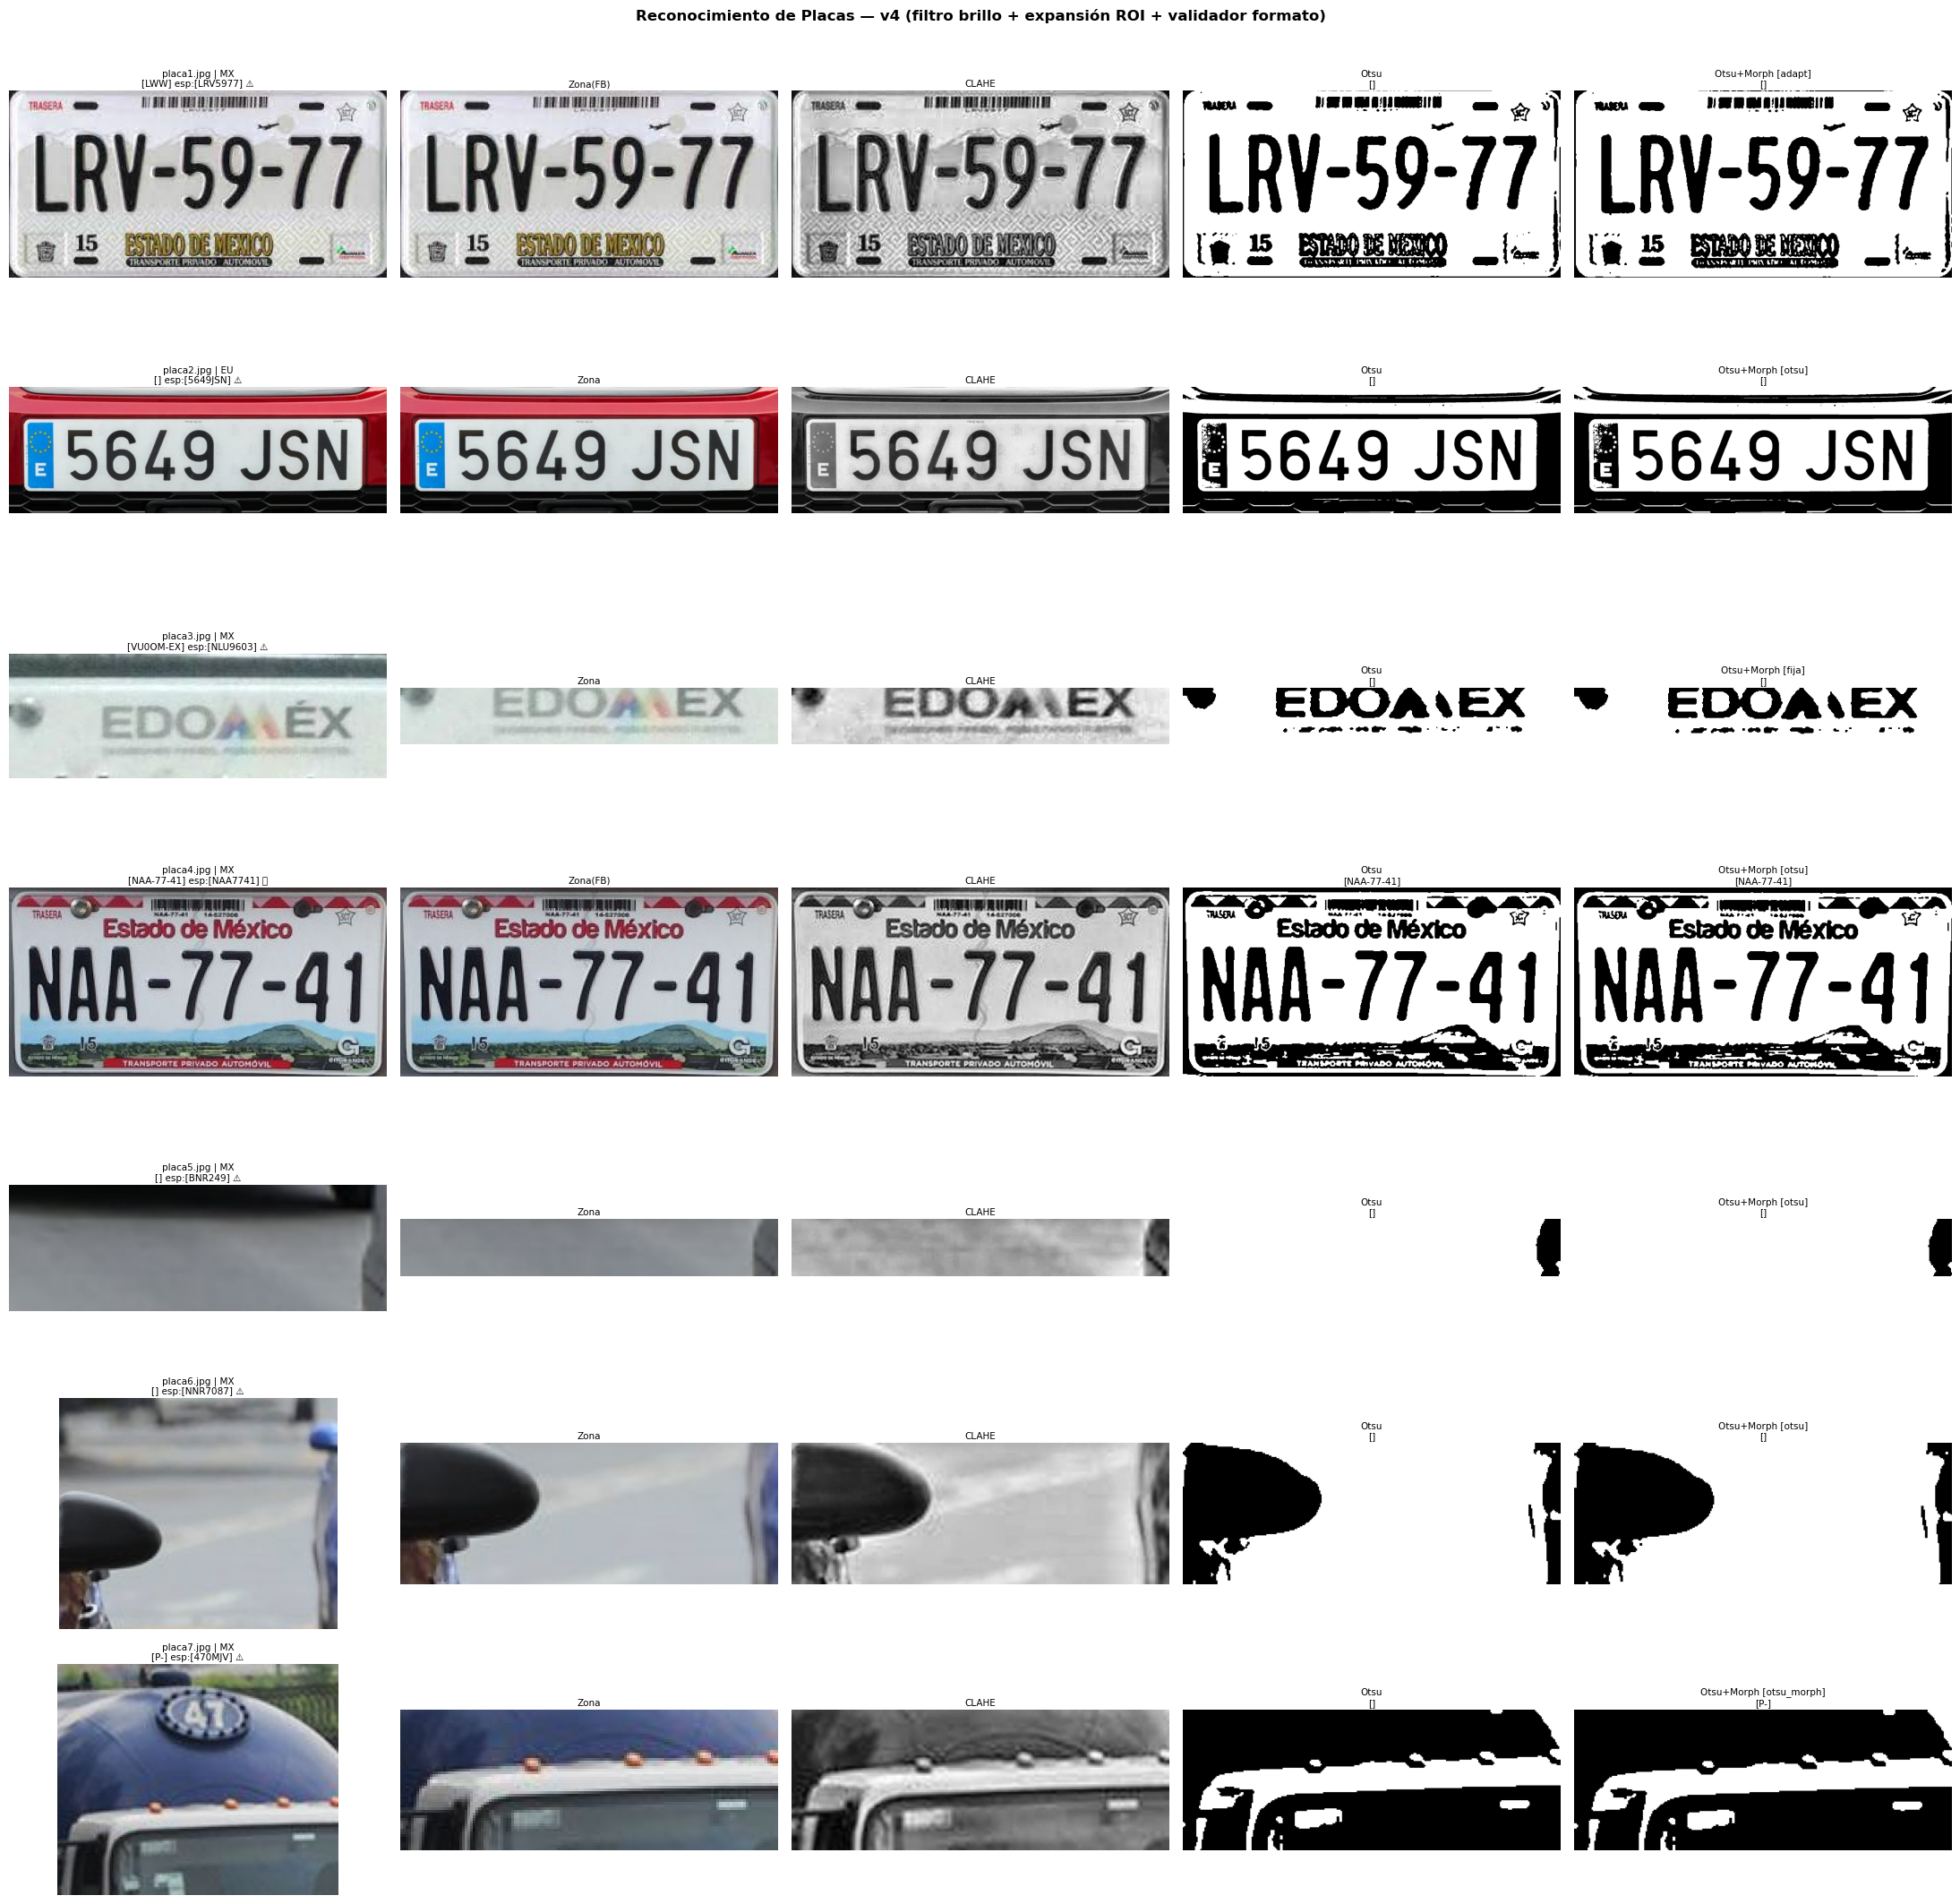

Grilla guardada como output_placas_v4.png ✅


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Grilla visual
# ═══════════════════════════════════════════════════════════════
#
# Columnas:
#   1 → Original (recorte Haar expandido)
#   2 → Zona de números
#   3 → CLAHE
#   4 → Otsu
#   5 → Otsu + Morph Close  (variante morfológica)

n    = len(resultados)
fig, axes = plt.subplots(n, 5, figsize=(22, 3.0 * n))
if n == 1:
    axes = [axes]

for fila, r in enumerate(resultados):
    et = r['etapas']
    gt_texto, _ = GROUND_TRUTH.get(r['imagen'], ('?', '?'))
    match_icon  = '✅' if r['match'] else '⚠️'

    imgs_row = [
        (et['original'],    True,  f"{r['imagen']} | {r['tipo']}\n[{r['texto']}] esp:[{gt_texto}] {match_icon}"),
        (et['zona_numeros'],True,  f"Zona{'(FB)' if r['es_fallback'] else ''}"),
        (et['clahe'],       False, 'CLAHE'),
        (et['bin_otsu'],    False, f"Otsu\n[{r['detalle']['otsu']}]"),
        (et['morph_otsu'],  False, f"Otsu+Morph [{r['metodo']}]\n[{r['detalle']['otsu_morph']}]"),
    ]

    for col, (img, es_color, titulo) in enumerate(imgs_row):
        ax = axes[fila][col]
        ax.imshow(img) if es_color else ax.imshow(img, cmap='gray')
        ax.set_title(titulo, fontsize=7.5, pad=3)
        ax.axis('off')

plt.suptitle('Reconocimiento de Placas — v4 (filtro brillo + expansión ROI + validador formato)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v4.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grilla guardada como output_placas_v4.png ✅')
